In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import plotly.subplots as sp
from plotly.subplots import make_subplots
import plotly.graph_objs as go

from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.decomposition import PCA

import random
import statistics

In [2]:
data_train = pd.read_csv("data/train.csv")
data_test = pd.read_csv("data/test.csv")
data_train.head()

,originalTitle,rating,startYear,endYear,runtimeMinutes,awardWins,numVotes,worstRating,bestRating,totalImages,...,titleType,awardNominationsExcludeWins,canHaveEpisodes,isRatable,isAdult,numRegions,userReviewsTotal,ratingCount,countryOfOrigin,genres
0,Neogenic Nightmare Chapter 3: Hydro-Man,"(7, 8]",1995,\N,\N,0.0,779,1,10,1,...,tvEpisode,0,False,True,0,1,0,781,['US'],"Action,Adventure,Animation"
1,Looping,"(5, 6]",1982,\N,\N,0.0,11,1,10,1,...,videoGame,0,False,True,0,1,0,11,['XWG'],Action
2,Idealnaya para,"(5, 6]",1992,\N,\N,0.0,38,1,10,1,...,movie,0,False,True,0,1,1,38,['RU'],Comedy
3,MasterChef Celebrity México,"(5, 6]",2021,\N,\N,0.0,15,1,10,22,...,tvSeries,0,True,True,0,1,0,15,['MX'],Reality-TV
4,Seutateueob,"(7, 8]",2020,2020,80,1.0,15718,1,10,347,...,tvSeries,1,True,True,0,32,452,15746,['KR'],"Comedy,Drama,Romance"


In [3]:
print("-------------------------- SHAPE -----------------------")
print(data_train.shape, f"-> {data_train.shape[0]} records and {data_train.shape[1]} features")
print("-------------------------- INFO ------------------------")
print(data_train.info())

-------------------------- SHAPE -----------------------
(16431, 23) -> 16431 records and 23 features
-------------------------- INFO ------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16431 entries, 0 to 16430
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   originalTitle                16431 non-null  object 
 1   rating                       16431 non-null  object 
 2   startYear                    16431 non-null  int64  
 3   endYear                      16431 non-null  object 
 4   runtimeMinutes               16431 non-null  object 
 5   awardWins                    13813 non-null  float64
 6   numVotes                     16431 non-null  int64  
 7   worstRating                  16431 non-null  int64  
 8   bestRating                   16431 non-null  int64  
 9   totalImages                  16431 non-null  int64  
 10  totalVideos                  16

In [4]:
data_train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
originalTitle,16431,16054,Episode #1.1,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,16431,10,"(7, 8]",4822,NaN,NaN,NaN,NaN,NaN,NaN,NaN
startYear,16431.0,NaN,NaN,NaN,1991.867081,26.12069,1878.0,1978.0,1997.0,2013.0,2024.0
endYear,16431,75,\N,15617,NaN,NaN,NaN,NaN,NaN,NaN,NaN
runtimeMinutes,16431,244,\N,4852,NaN,NaN,NaN,NaN,NaN,NaN,NaN
awardWins,13813.0,NaN,NaN,NaN,0.491855,2.974264,0.0,0.0,0.0,0.0,145.0
numVotes,16431.0,NaN,NaN,NaN,1492.153551,20137.708096,5.0,15.0,36.0,148.5,966565.0
worstRating,16431.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
bestRating,16431.0,NaN,NaN,NaN,10.0,0.0,10.0,10.0,10.0,10.0,10.0
totalImages,16431.0,NaN,NaN,NaN,11.477025,74.254261,0.0,1.0,1.0,6.0,3504.0


## DATA UNDERSTANDING AND PREPARATION

### 1) Data Semantics
- originalTitle: 		
Original title, in the original language.
Nominal
Non-Null
- runtimeMinutes: 		
Primary runtime of the title, in minutes.
Ratio
Non-Null
- isAdult:		
Whether or not the title is for adult. 0: non-adult title; 1: adult title.
Binary
- startYear: 			
Represents the release year of a title. In the case of TV Series, it is the series start year.
Ordinal
- endYear:
TV Series end year.
Numeric
- numVotes:
Number of votes the title has received.
Numeric
- numRegions:
The regions number for this version of the title.
Nominal
- worstRating: 
Worst title rating.
Ordinal
- bestRating:
Best title rating.
Ordinal
- canHaveEpisodes:
Whether or not the title can have episodes.
Binary
- isRatable:
Whether or not the title can be rated by users.
Binary
- totalImages:
Total Number of Images for the title within the IMDb title page.
Numeric
- totalVideos: 
Total Number of Videos for the title within the IMDb title page.
Numeric
- totalCredits:
Total Number of Credits for the title.
Numeric
- criticReviewsTotal:
Total Number of Critic Reviews.
Numeric
- awardWins:
Number of awards the title won.
Numeric
- awardNominationsExcludeWins:
Number of award nominations excluding wins.
Numeric
- titleType:
The type/format of the title (e.g. movie, short, tvseries, tvepisode, video, etc).
Categorical
- rating:
IMDB title rating class.
Numeric
- ratingCount: 
The total number of user ratings submitted for the title.
Ratio
- countryOfOrigin: 
The country where the title was primarily produced.
Categorical
- genres: 
The genre(s) associated with the title (e.g., drama, comedy, action).
Categorical
- userReviewsTotal:
Total Number of Users Reviews.
Ratio

In [5]:
# Subset of columns based on dtype
int_subset = data_train.select_dtypes(include=['int'])
float_subset = data_train.select_dtypes(include=['float'])
bool_subset = data_train.select_dtypes(include=['bool'])
object_subset = data_train.select_dtypes(include=['object'])

subsets = {"int" : int_subset, "float": float_subset, "bool": bool_subset, "object" : object_subset}

for t, subset in subsets.items():
    print(f"Type {t} Features:")
    print(subset.columns.tolist())
    print("\n")

Type int Features:
['startYear', 'numVotes', 'worstRating', 'bestRating', 'totalImages', 'totalVideos', 'totalCredits', 'criticReviewsTotal', 'awardNominationsExcludeWins', 'isAdult', 'numRegions', 'userReviewsTotal', 'ratingCount']


Type float Features:
['awardWins']


Type bool Features:
['canHaveEpisodes', 'isRatable']


Type object Features:
['originalTitle', 'rating', 'endYear', 'runtimeMinutes', 'titleType', 'countryOfOrigin', 'genres']




In [6]:
# Cast columns to right type.
data_train['endYear'] = pd.to_numeric(data_train['endYear'], errors='coerce', downcast='integer')
data_train['runtimeMinutes'] = pd.to_numeric(data_train['runtimeMinutes'], errors='coerce', downcast='integer')
data_train["isAdult"] = [val != 0 for val in data_train['isAdult']]

data_test['endYear'] = pd.to_numeric(data_test['endYear'], errors='coerce', downcast='integer')
data_test['runtimeMinutes'] = pd.to_numeric(data_test['runtimeMinutes'], errors='coerce', downcast='integer')
data_test["isAdult"] = [val != 0 for val in data_test['isAdult']]

# Clean ratings (from "(x, y]" to y : int)
data_train['rating'] = data_train['rating'].apply( lambda rt : int(rt.split(',')[1].replace(']', '')))

data_test['rating'] = data_test['rating'].apply( lambda rt : int(rt.split(',')[1].replace(']', '')))

# Check that bestRating and worstRating are constant columns.
print('entries in bestRating != 10:', len(data_train[data_train['bestRating'] != 10]))
print('entries in worstRating != 1:', len(data_train[data_train['worstRating'] != 1]))

# Removing columns bestRating and worstRating, since they are constant columns
data_train.drop(['bestRating', 'worstRating'], axis=1, inplace=True)

data_test.drop(['bestRating', 'worstRating'], axis=1, inplace=True)

data_train.head()

entries in bestRating != 10: 0
entries in worstRating != 1: 0


,originalTitle,rating,startYear,endYear,runtimeMinutes,awardWins,numVotes,totalImages,totalVideos,totalCredits,...,titleType,awardNominationsExcludeWins,canHaveEpisodes,isRatable,isAdult,numRegions,userReviewsTotal,ratingCount,countryOfOrigin,genres
0,Neogenic Nightmare Chapter 3: Hydro-Man,8,1995,NaN,NaN,0.0,779,1,0,21,...,tvEpisode,0,False,True,False,1,0,781,['US'],"Action,Adventure,Animation"
1,Looping,6,1982,NaN,NaN,0.0,11,1,0,1,...,videoGame,0,False,True,False,1,0,11,['XWG'],Action
2,Idealnaya para,6,1992,NaN,NaN,0.0,38,1,0,24,...,movie,0,False,True,False,1,1,38,['RU'],Comedy
3,MasterChef Celebrity México,6,2021,NaN,NaN,0.0,15,22,0,56,...,tvSeries,0,True,True,False,1,0,15,['MX'],Reality-TV
4,Seutateueob,8,2020,2020.0,80.0,1.0,15718,347,2,47,...,tvSeries,1,True,True,False,32,452,15746,['KR'],"Comedy,Drama,Romance"


In [7]:
# Check how many rows contains '\N' in object type columns and replace them with None.
print( 'Object-type columns containing \"\\N\":', len(data_train[data_train.map(lambda x: x == '\\N').any(axis=1)]))
data_train.replace('\\N', None, inplace=True)
data_test.replace('\\N', None, inplace=True)

print(len(data_train[data_train.map(lambda x: x == '\\N').any(axis=1)]))
print(len(data_test[data_train.map(lambda x: x == '\\N').any(axis=1)]))
data_train.info()

# Find Duplicates (rows in general)
duplicated_rows_train = data_train[data_train.duplicated(keep=False)].reset_index(drop=True)
duplicated_rows_test = data_test[data_test.duplicated(keep=False)].reset_index(drop=True)

print(len(duplicated_rows_train))
print(len(duplicated_rows_test))
# there are no duplicated rows

Object-type columns containing "\N": 382
0
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16431 entries, 0 to 16430
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   originalTitle                16431 non-null  object 
 1   rating                       16431 non-null  int64  
 2   startYear                    16431 non-null  int64  
 3   endYear                      814 non-null    float64
 4   runtimeMinutes               11579 non-null  float64
 5   awardWins                    13813 non-null  float64
 6   numVotes                     16431 non-null  int64  
 7   totalImages                  16431 non-null  int64  
 8   totalVideos                  16431 non-null  int64  
 9   totalCredits                 16431 non-null  int64  
 10  criticReviewsTotal           16431 non-null  int64  
 11  titleType                    16431 non-null  object 
 12  awardNominationsExcludeWins  

C:\Users\curia\AppData\Local\Temp\ipykernel_26176\3425143206.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(len(data_test[data_train.map(lambda x: x == '\\N').any(axis=1)]))


Considerazioni:
- awardWins da float dovrebbe essere un int
- isAdult da int dovrebbe essere boolean
- ratingCount e numVotes sono quasi perfettamente uguali
- rating è oggetto (una lista strana) e dovrebbe essere int 
- endYear dovrebbe essere int ma è strapieno di Missing Values, quasi il totale
- runtimeMinutes e awardWins presentano diversi MissingValues
- gestire i missno di awardWins, runtimeMinutes e endYear così da poterli convertire in int da float
- le uniche liste sono countryOfOrigin e genres: vedere se possono essere modificate per usarle

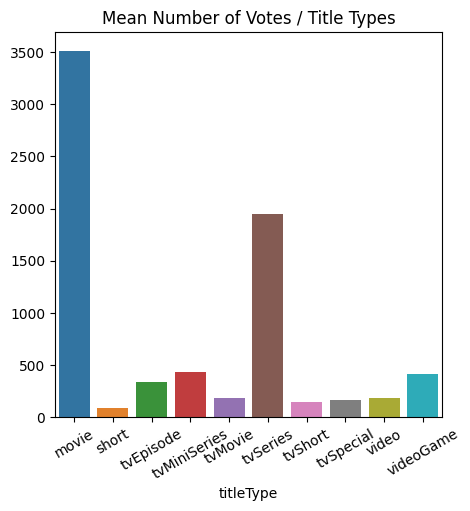

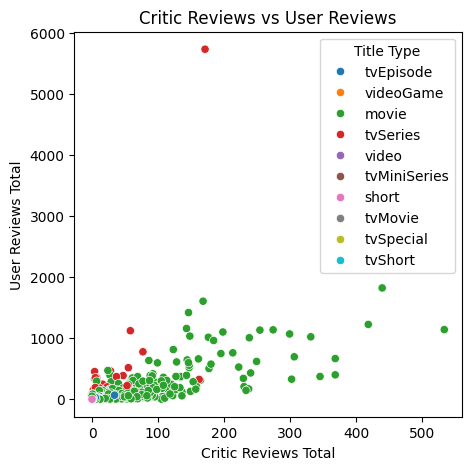

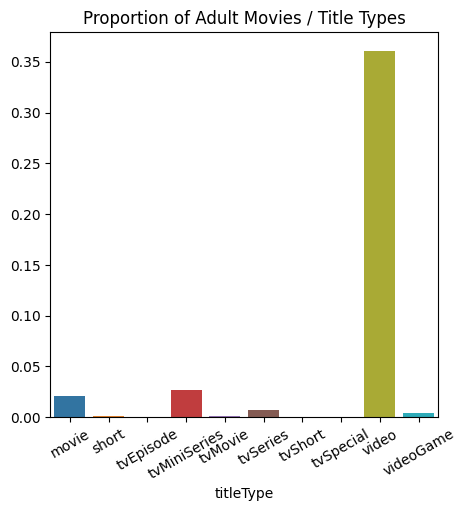

In [8]:
# qualche grafico di osservazione
# here we can see a mean of number of votes based on the type of the title (movie, tv series, short, etc.)
votes_mean = data_train.groupby('titleType')['numVotes'].mean()

plt.figure(figsize=(5,5))

cmap = sns.light_palette("red", as_cmap=True)
rank = votes_mean.argsort().argsort()
sns.barplot(x=votes_mean.index, y=votes_mean.values, hue=votes_mean.index, legend=False)

plt.xticks(rotation=30)
plt.title('Mean Number of Votes / Title Types')
plt.show()

# here we can see the number of users and critics reviews based on the type of the title
plt.figure(figsize=(5, 5))
sns.scatterplot(x='criticReviewsTotal', y='userReviewsTotal', data=data_train, hue='titleType', palette='tab10')
plt.title('Critic Reviews vs User Reviews')
plt.xlabel('Critic Reviews Total')
plt.ylabel('User Reviews Total')
plt.legend(title='Title Type')
plt.show()

# Calcola la proporzione di film vietati ai minori per ciascun tipo di titolo
adult_ratio = data_train.groupby('titleType')['isAdult'].mean()
plt.figure(figsize=(5, 5))
sns.barplot(x=adult_ratio.index, y=adult_ratio.values, hue=adult_ratio.index, legend=False)
plt.xticks(rotation=30)
plt.title('Proportion of Adult Movies / Title Types')
plt.show()

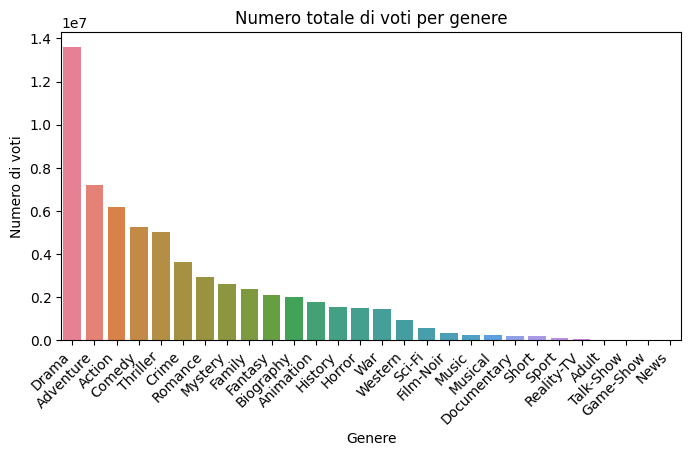

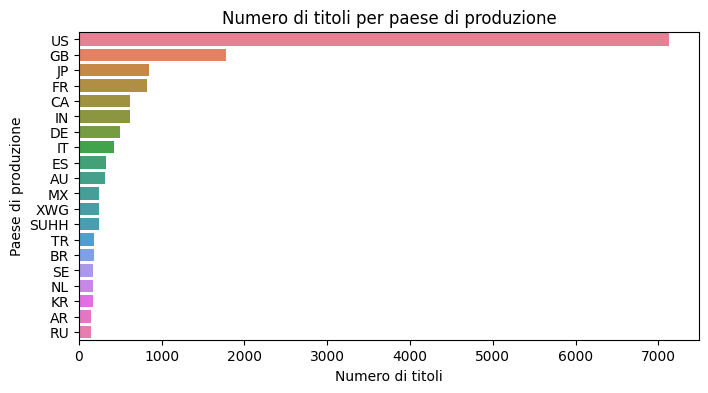

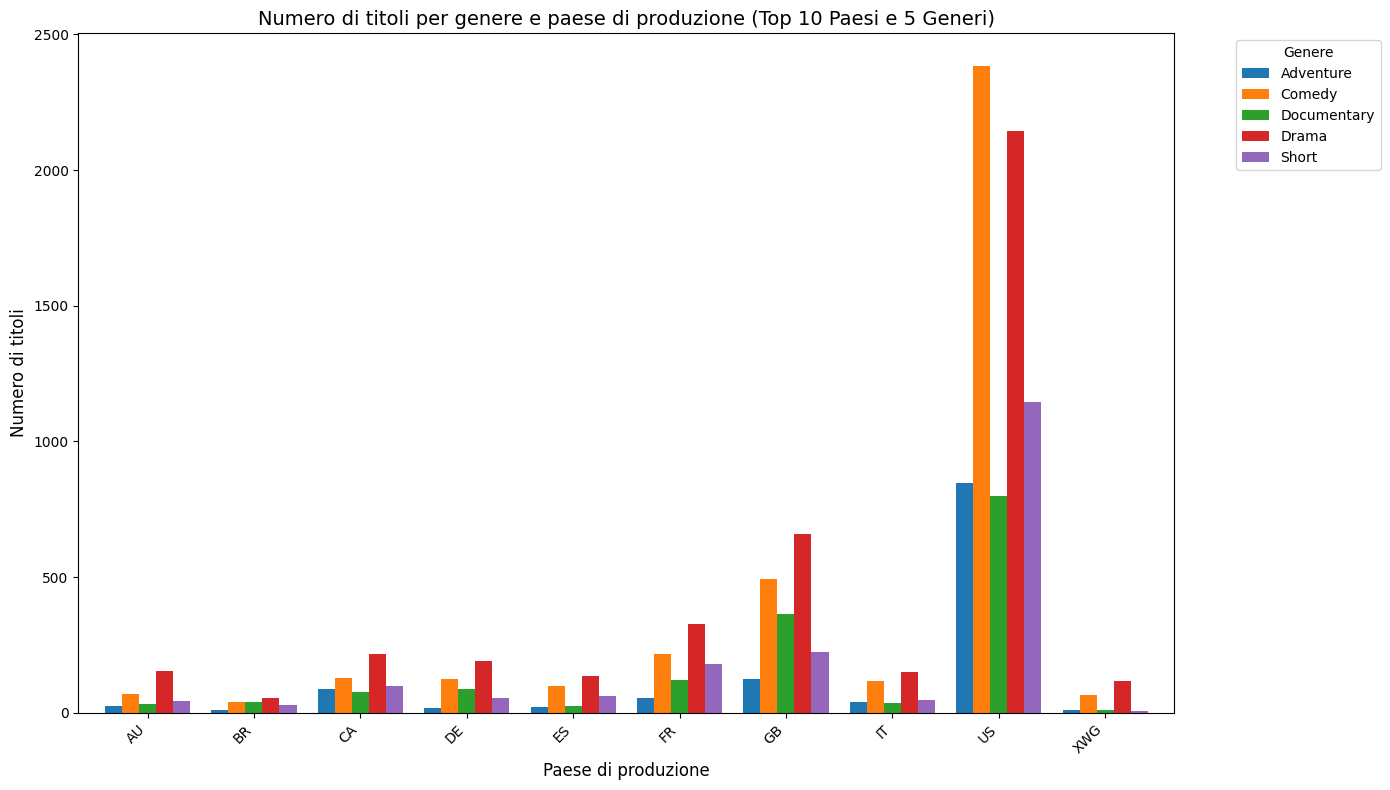

In [9]:

# Esplodiamo la colonna 'genres' e "countryOfOrigin"
data_genres = data_train.assign(genres=data_train['genres'].str.split(',')).explode('genres')

# grafico 1
# Calcolare i voti totali per genere
votes_by_genre = data_genres.groupby('genres')['numVotes'].sum().sort_values(ascending=False)
# Creare un grafico a barre
plt.figure(figsize=(8, 4))
sns.barplot(x=votes_by_genre.index, y=votes_by_genre.values, hue= votes_by_genre.index, legend = False)
plt.xticks(rotation=45, ha='right')
plt.title('Numero totale di voti per genere')
plt.xlabel('Genere')
plt.ylabel('Numero di voti')
plt.show()

#grafico 2
# Pulizia della colonna 'countryOfOrigin'
data_countries = data_train.assign(countryOfOrigin=data_train['countryOfOrigin'].str.strip("[]").str.replace("'", "").str.split(',')).explode('countryOfOrigin')

# Rimuovere eventuali spazi bianchi
data_countries['countryOfOrigin'] = data_countries['countryOfOrigin'].str.strip()

# Contare il numero di titoli per paese
titles_by_country = data_countries['countryOfOrigin'].value_counts().head(20)  # I primi 20 paesi

# Creare un grafico a barre
plt.figure(figsize=(8, 4))
sns.barplot(x=titles_by_country.values, y=titles_by_country.index, hue= titles_by_country.index, legend = False)
plt.title('Numero di titoli per paese di produzione')
plt.xlabel('Numero di titoli')
plt.ylabel('Paese di produzione')
plt.show()

# grafico3
# Pulizia delle colonne 'genres' e 'countryOfOrigin'
data_cleaned = data_train.assign(
    genres=data_train['genres'].str.strip("[]").str.replace("'", "").str.split(','),
    countryOfOrigin=data_train['countryOfOrigin'].str.strip("[]").str.replace("'", "").str.split(',')
)
data_genres_countries = data_cleaned.explode('genres').explode('countryOfOrigin')

# Rimuovere eventuali spazi bianchi e valori nulli
data_genres_countries['genres'] = data_genres_countries['genres'].str.strip()
data_genres_countries['countryOfOrigin'] = data_genres_countries['countryOfOrigin'].str.strip()
data_genres_countries = data_genres_countries.dropna(subset=['genres', 'countryOfOrigin'])

# Contare il numero di titoli per ogni combinazione di genere e paese
genre_country_counts = data_genres_countries.groupby(['countryOfOrigin', 'genres']).size().reset_index(name='count')

# Creare una tabella pivot
pivot = genre_country_counts.pivot(index='countryOfOrigin', columns='genres', values='count')

# Riempire i valori NaN con 0 per evitare errori nella heatmap
pivot = pivot.fillna(0)
# Selezionare le combinazioni più comuni (es. primi 10 paesi e 5 generi principali)
top_countries = genre_country_counts['countryOfOrigin'].value_counts().head(10).index
top_genres = genre_country_counts['genres'].value_counts().head(5).index

# Filtrare il dataset per i top paesi e generi
filtered_data = genre_country_counts[
    (genre_country_counts['countryOfOrigin'].isin(top_countries)) &
    (genre_country_counts['genres'].isin(top_genres))
]

# Creare un pivot per il grafico
pivot_grouped = filtered_data.pivot(index='countryOfOrigin', columns='genres', values='count').fillna(0)

# Creare il grafico a barre raggruppate
pivot_grouped.plot(kind='bar', figsize=(14, 8), width=0.8)

# Personalizzare il grafico
plt.title('Numero di titoli per genere e paese di produzione (Top 10 Paesi e 5 Generi)', fontsize=14)
plt.xlabel('Paese di produzione', fontsize=12)
plt.ylabel('Numero di titoli', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(title='Genere', fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Mostrare il grafico
plt.show()


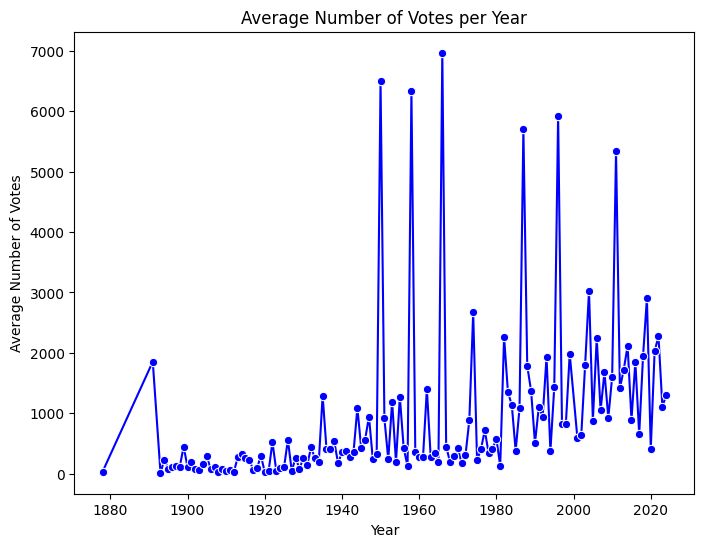

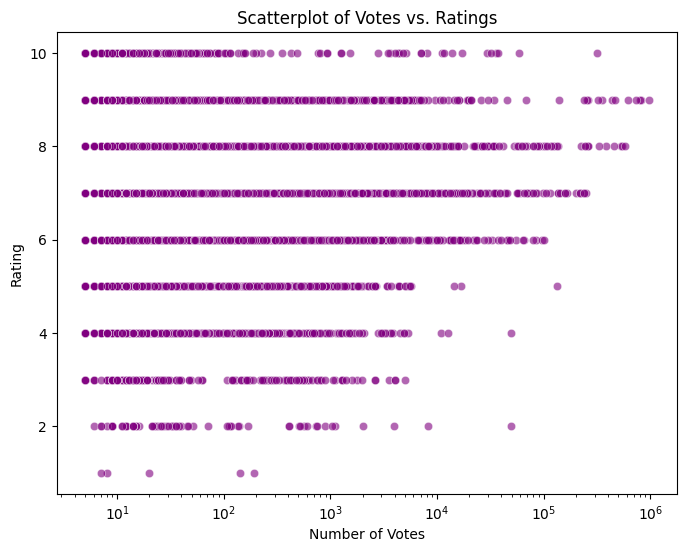

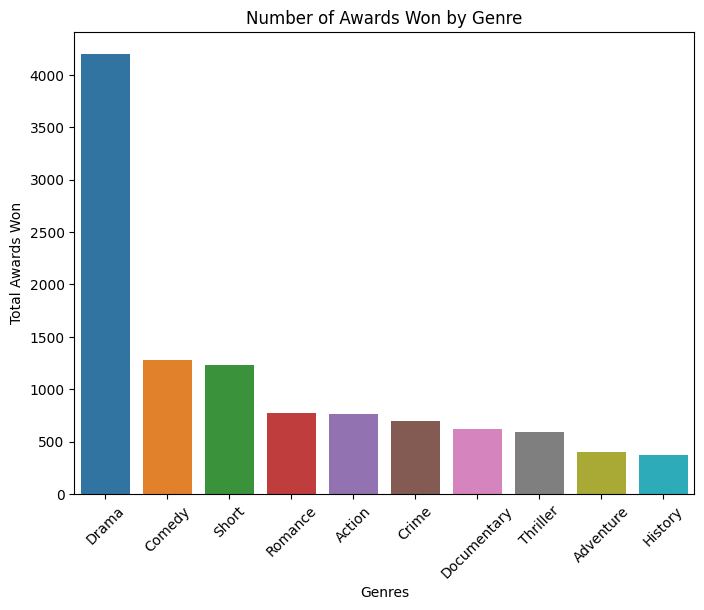

In [10]:
# Lineplot: Average Number of Votes per Year
avg_votes_per_year = data_train.groupby('startYear')['numVotes'].mean().reset_index()
plt.figure(figsize=(8, 6))
sns.lineplot(x='startYear', y='numVotes', data=avg_votes_per_year, marker='o', color='blue')
plt.title('Average Number of Votes per Year')
plt.xlabel('Year')
plt.ylabel('Average Number of Votes')
plt.show()

# Scatterplot: Votes vs. Ratings
plt.figure(figsize=(8, 6))
sns.scatterplot(x='numVotes', y='rating', data=data_train, alpha=0.6, color='purple')
plt.title('Scatterplot of Votes vs. Ratings')
plt.xlabel('Number of Votes')
plt.ylabel('Rating')
plt.xscale('log')  # Log scale for better visualization if 'numVotes' has a wide range
plt.show()

# Barplot: Number of Awards Won by Genre
# Esplodiamo la colonna 'genres' e "countryOfOrigin"
data_genres = data_train.assign(genres=data_train['genres'].str.split(',')).explode('genres')
plt.figure(figsize=(8, 6))
genre_awards = data_genres.groupby('genres')['awardWins'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=genre_awards.index, y=genre_awards.values, hue=genre_awards.index, legend = False)
plt.title('Number of Awards Won by Genre')
plt.xlabel('Genres')
plt.ylabel('Total Awards Won')
plt.xticks(rotation=45)
plt.show()

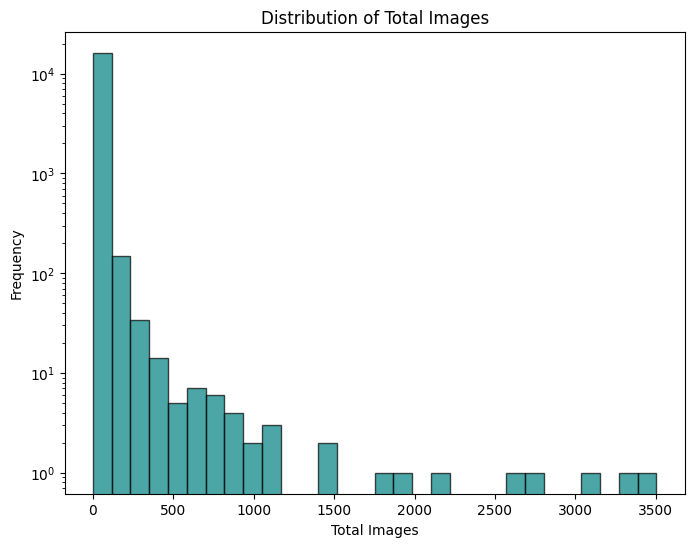

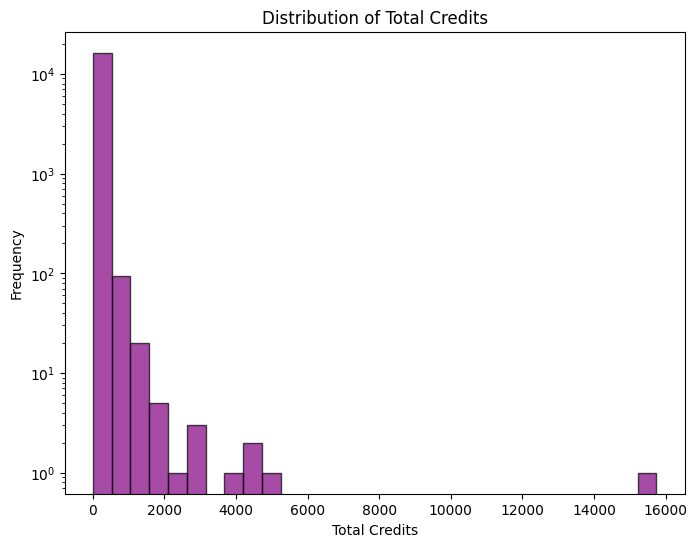

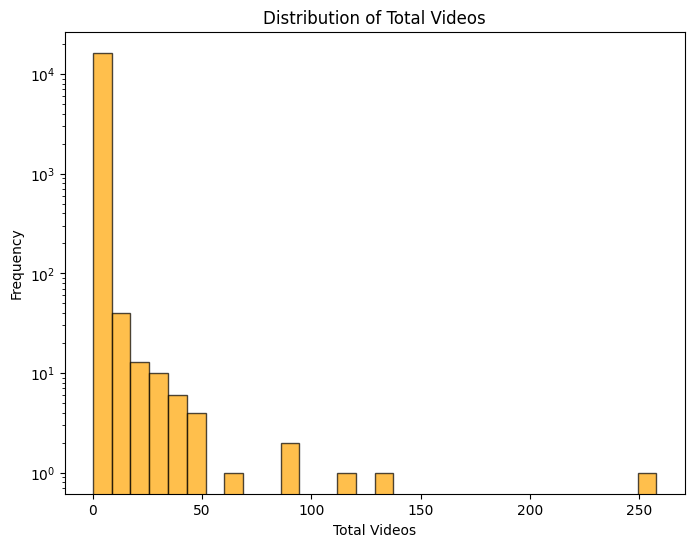

In [37]:
# Histogram: Distribution of Total Images, Total Credits, Total Videos
plt.figure(figsize=(8, 6))
plt.hist(data_train['totalImages'], bins=30, color='teal', alpha=0.7, edgecolor='black')
plt.title('Distribution of Total Images')
plt.xlabel('Total Images')
plt.ylabel('Frequency')
plt.yscale('log')  # Log scale to better visualize the skewed distribution
plt.show()

plt.figure(figsize=(8, 6))
plt.hist(data_train['totalCredits'], bins=30, color='purple', alpha=0.7, edgecolor='black')
plt.title('Distribution of Total Credits')
plt.xlabel('Total Credits')
plt.ylabel('Frequency')
plt.yscale('log')  # Log scale to better visualize the skewed distribution
plt.show()

plt.figure(figsize=(8, 6))
plt.hist(data_train['totalVideos'], bins=30, color='orange', alpha=0.7, edgecolor='black')
plt.title('Distribution of Total Videos')
plt.xlabel('Total Videos')
plt.ylabel('Frequency')
plt.yscale('log')  # Log scale to better visualize the skewed distribution
plt.show()


### Missing Values

In [12]:
# Check presence of NaNs
nan_percentage = data_train.isna().mean() * 100
nan_percentage

originalTitle                   0.000000
rating                          0.000000
startYear                       0.000000
endYear                        95.045950
runtimeMinutes                 29.529548
awardWins                      15.933297
numVotes                        0.000000
totalImages                     0.000000
totalVideos                     0.000000
totalCredits                    0.000000
criticReviewsTotal              0.000000
titleType                       0.000000
awardNominationsExcludeWins     0.000000
canHaveEpisodes                 0.000000
isRatable                       0.000000
isAdult                         0.000000
numRegions                      0.000000
userReviewsTotal                0.000000
ratingCount                     0.000000
countryOfOrigin                 0.000000
genres                          2.324874
dtype: float64

In [13]:
# being almost all missing values, endYear will be dropped
data_train.drop(columns=['endYear'], inplace=True)

data_test.drop(columns=['endYear'], inplace=True)

data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16431 entries, 0 to 16430
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   originalTitle                16431 non-null  object 
 1   rating                       16431 non-null  int64  
 2   startYear                    16431 non-null  int64  
 3   runtimeMinutes               11579 non-null  float64
 4   awardWins                    13813 non-null  float64
 5   numVotes                     16431 non-null  int64  
 6   totalImages                  16431 non-null  int64  
 7   totalVideos                  16431 non-null  int64  
 8   totalCredits                 16431 non-null  int64  
 9   criticReviewsTotal           16431 non-null  int64  
 10  titleType                    16431 non-null  object 
 11  awardNominationsExcludeWins  16431 non-null  int64  
 12  canHaveEpisodes              16431 non-null  bool   
 13  isRatable       

In [14]:
# being all True, isRatable will be dropped
false_count = len(data_train[data_train['isRatable'] == False])
print(false_count)

data_train.drop(columns=['isRatable'], inplace=True)
data_test.drop(columns=['isRatable'], inplace=True)

data_train.info()

0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16431 entries, 0 to 16430
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   originalTitle                16431 non-null  object 
 1   rating                       16431 non-null  int64  
 2   startYear                    16431 non-null  int64  
 3   runtimeMinutes               11579 non-null  float64
 4   awardWins                    13813 non-null  float64
 5   numVotes                     16431 non-null  int64  
 6   totalImages                  16431 non-null  int64  
 7   totalVideos                  16431 non-null  int64  
 8   totalCredits                 16431 non-null  int64  
 9   criticReviewsTotal           16431 non-null  int64  
 10  titleType                    16431 non-null  object 
 11  awardNominationsExcludeWins  16431 non-null  int64  
 12  canHaveEpisodes              16431 non-null  bool   
 13  isAdult       

In [15]:
# having a lot of zeroes, it is best to fill missing values with this number
data_train['awardWins'].fillna(0, inplace=True)  # Imputa i valori mancanti con 0
data_test['awardWins'].fillna(0, inplace=True)  # Imputa i valori mancanti con 0

# Controllo dei risultati
print(data_train.isnull().sum())  # Stampa il numero di valori mancanti per ogni colonna
print(data_test.isnull().sum())

originalTitle                     0
rating                            0
startYear                         0
runtimeMinutes                 4852
awardWins                         0
numVotes                          0
totalImages                       0
totalVideos                       0
totalCredits                      0
criticReviewsTotal                0
titleType                         0
awardNominationsExcludeWins       0
canHaveEpisodes                   0
isAdult                           0
numRegions                        0
userReviewsTotal                  0
ratingCount                       0
countryOfOrigin                   0
genres                          382
dtype: int64
originalTitle                     0
rating                            0
startYear                         0
runtimeMinutes                 1660
awardWins                         0
numVotes                          0
totalImages                       0
totalVideos                       0
totalCredits   

C:\Users\curia\AppData\Local\Temp\ipykernel_26176\855388954.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_train['awardWins'].fillna(0, inplace=True)  # Imputa i valori mancanti con 0
C:\Users\curia\AppData\Local\Temp\ipykernel_26176\855388954.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alw

In [16]:
# Calcolo della mediana complessiva
combined_runtime = pd.concat([data_train['runtimeMinutes'], data_test['runtimeMinutes']])
median_runtime_total = combined_runtime.median()

# Calcolo della media complessiva
mean_runtime_total = combined_runtime.mean()

print(f"Media totale: {mean_runtime_total}")
print(f"Mediana totale: {median_runtime_total}")

# Riempimento dei valori mancanti con la mediana totale, dato che è meno influenzata dagli outliers
data_train['runtimeMinutes'].fillna(median_runtime_total, inplace=True)
data_test['runtimeMinutes'].fillna(median_runtime_total, inplace=True)

# Verifica
data_train.info()
data_test.info()

Media totale: 61.61849710982659
Mediana totale: 59.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16431 entries, 0 to 16430
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   originalTitle                16431 non-null  object 
 1   rating                       16431 non-null  int64  
 2   startYear                    16431 non-null  int64  
 3   runtimeMinutes               16431 non-null  float64
 4   awardWins                    16431 non-null  float64
 5   numVotes                     16431 non-null  int64  
 6   totalImages                  16431 non-null  int64  
 7   totalVideos                  16431 non-null  int64  
 8   totalCredits                 16431 non-null  int64  
 9   criticReviewsTotal           16431 non-null  int64  
 10  titleType                    16431 non-null  object 
 11  awardNominationsExcludeWins  16431 non-null  int64  
 12  canHaveEpisodes      

C:\Users\curia\AppData\Local\Temp\ipykernel_26176\3410568482.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_train['runtimeMinutes'].fillna(median_runtime_total, inplace=True)
C:\Users\curia\AppData\Local\Temp\ipykernel_26176\3410568482.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always be

In [17]:
# genres possiede solo il 2% di missing values, essendo una colonna di liste che presentano generi, useremo una lista con l'elemento "unknown"
data_train['genres'] = data_train['genres'].apply(lambda x: "Unknown" if pd.isna(x) else x)

data_test['genres'] = data_test['genres'].apply(lambda x: "Unknown" if pd.isna(x) else x)


In [18]:
# essendo sia runtimeMinutes che awardWins classificati come float, ma essendo int, li convertiamo
# Seleziona tutte le colonne float
float_columns_train = data_train.select_dtypes(include=['float']).columns
float_columns_test = data_test.select_dtypes(include=['float']).columns

# Converte tutte le colonne float in int
data_train[float_columns_train] = data_train[float_columns_train].astype('int64')  # Usa 'int64' per supportare i NaN come valori interi
data_test[float_columns_test] = data_test[float_columns_test].astype('int64')

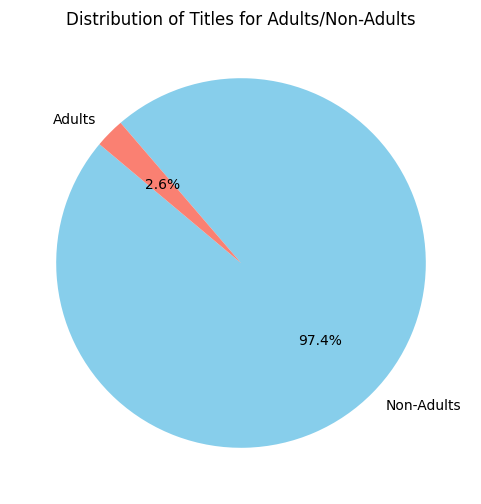

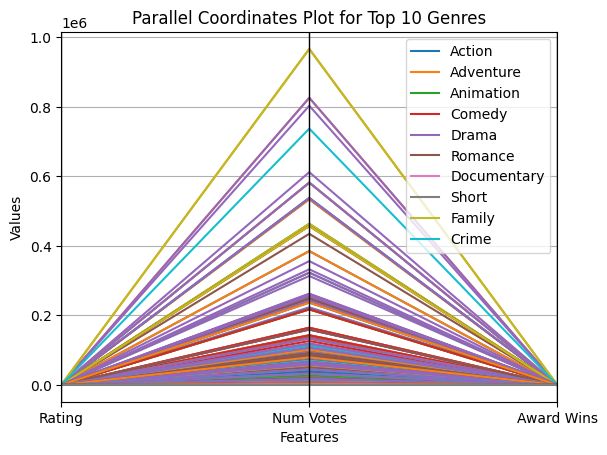

In [19]:
# grafico 1
plt.figure(figsize=(6, 6))
data_train['isAdult'].value_counts().plot.pie(
    autopct='%1.1f%%', labels=['Non-Adults', 'Adults'], colors=['skyblue', 'salmon'], startangle=140
)
plt.title('Distribution of Titles for Adults/Non-Adults')
plt.ylabel('')
plt.show() 

# grafico 2
from pandas.plotting import parallel_coordinates
# Esplodi la colonna 'genres' in righe separate
data_genres = data_train.assign(genres=data_train['genres'].str.split(',')).explode('genres')
# Ottieni i 10 generi più comuni
top_10_genres = data_genres['genres'].value_counts().head(10).index
# Filtra i dati per includere solo i generi principali
data_genres_top10 = data_genres[data_genres['genres'].isin(top_10_genres)]
# Rimuovi righe con valori mancanti
data_genres_top10 = data_genres_top10.dropna(subset=['rating', 'numVotes', 'awardWins'])
# Grafico parallel coordinates
parallel_coordinates(data_genres_top10, class_column='genres', cols=['rating', 'numVotes', 'awardWins'], color=sns.color_palette('tab10'))
plt.title('Parallel Coordinates Plot for Top 10 Genres')
plt.xlabel('Features')
plt.ylabel('Values')
plt.xticks([0, 1, 2], ['Rating', 'Num Votes', 'Award Wins'])
plt.show()


# analisi grafico 2
Analisi del grafico
Distribuzione uniforme per rating:

I valori di rating sembrano distribuiti in modo simile per la maggior parte dei generi. Non ci sono generi con valori estremi (molto alti o bassi).
Differenze marcate in numVotes:

Il numero di voti (numVotes) è un discriminante significativo. Alcuni generi, come "Drama" e "Action", tendono ad avere un numero di voti molto alto, mentre generi come "Short", "Family", e "Crime" ne hanno relativamente pochi.
awardWins più bassi per alcuni generi:

Generi come "Drama" e "Documentary" mostrano un maggiore numero di premi vinti, rispetto a generi come "Family" o "Short", che generalmente ottengono meno riconoscimenti.
Picchi per alcuni generi specifici:

"Drama" e "Documentary" si distinguono come generi con un buon bilanciamento tra i tre parametri (rating, numVotes, awardWins).
"Short" e "Family" tendono a essere poco rappresentati in termini di numVotes e awardWins.

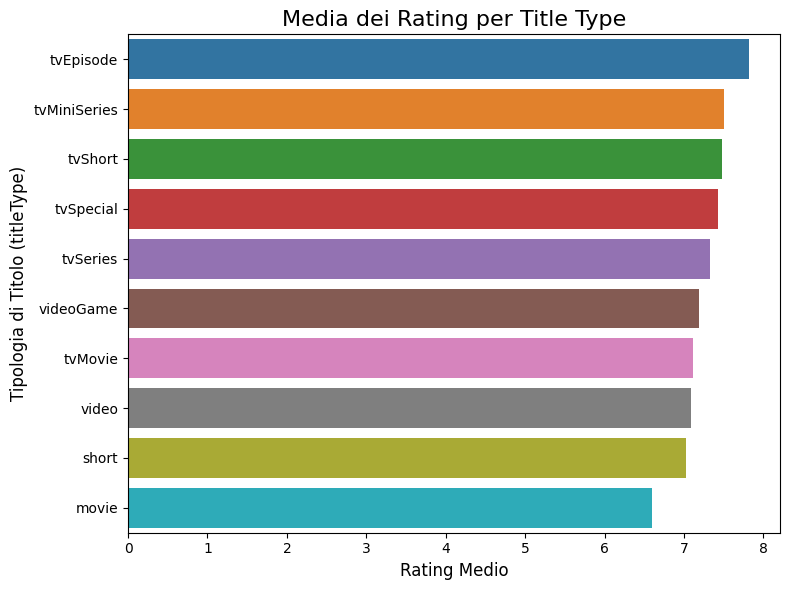

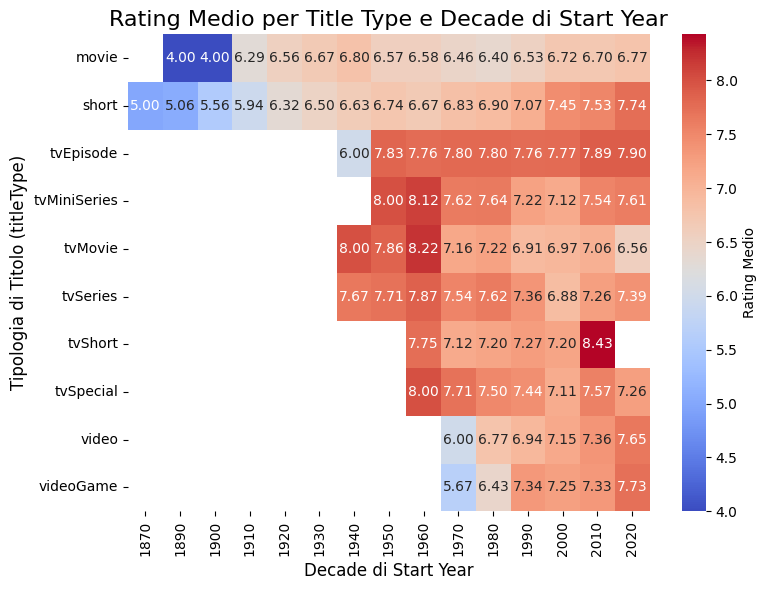

In [20]:
# grafico 3
# Calcoliamo la media dei rating per ogni tipo di titolo
rating_by_type = data_train.groupby('titleType')['rating'].mean().sort_values(ascending=False).reset_index()

# Creazione del barplot
plt.figure(figsize=(8, 6))
sns.barplot(x='rating', y='titleType', data=rating_by_type, hue = "titleType", legend = False)

plt.title('Media dei Rating per Title Type', fontsize=16)
plt.xlabel('Rating Medio', fontsize=12)
plt.ylabel('Tipologia di Titolo (titleType)', fontsize=12)
plt.tight_layout()
plt.show()

# grafico 4
# Creiamo una colonna per categorizzare 'startYear' in intervalli (decadi)
data_train['startYearDecade'] = (data_train['startYear'] // 10) * 10

# Calcoliamo la media dei rating per combinazioni di titleType e decade
heatmap_data = data_train.groupby(['titleType', 'startYearDecade'])['rating'].mean().unstack()

# Creazione della heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar_kws={'label': 'Rating Medio'}
)

plt.title('Rating Medio per Title Type e Decade di Start Year', fontsize=16)
plt.xlabel('Decade di Start Year', fontsize=12)
plt.ylabel('Tipologia di Titolo (titleType)', fontsize=12)
plt.tight_layout()
plt.show()





In [21]:
# delete the plus column used for the plot
data_train = data_train.drop(columns=['startYearDecade'])

In [22]:
data_train.describe().T

,count,mean,std,min,25%,50%,75%,max
rating,16431.0,7.155620,1.386902,1.0,6.0,7.0,8.0,10.0
startYear,16431.0,1991.867081,26.120690,1878.0,1978.0,1997.0,2013.0,2024.0
runtimeMinutes,16431.0,60.566308,43.755964,0.0,40.0,59.0,80.0,3000.0
awardWins,16431.0,0.413487,2.732959,0.0,0.0,0.0,0.0,145.0
numVotes,16431.0,1492.153551,20137.708096,5.0,15.0,36.0,148.5,966565.0
totalImages,16431.0,11.477025,74.254261,0.0,1.0,1.0,6.0,3504.0
totalVideos,16431.0,0.271499,3.115448,0.0,0.0,0.0,0.0,258.0
totalCredits,16431.0,61.341976,174.017450,0.0,16.0,34.0,65.0,15742.0
criticReviewsTotal,16431.0,2.785527,15.411389,0.0,0.0,0.0,1.0,533.0
awardNominationsExcludeWins,16431.0,0.558883,3.955372,0.0,0.0,0.0,0.0,197.0


To read the extended explanation of these data, consult the file "overall-int-columns.txt".

### Outliers

In [23]:
from scipy.stats import kurtosis, skew

# Initialize an empty dictionary to store the results
results = {'Variable': [], 'Excess Kurtosis': [], 'Skewness': []}

for f in data_train.select_dtypes(include=['int']):
    # Append the results to the dictionary
    results['Variable'].append(f)
    results['Excess Kurtosis'].append(kurtosis(data_train[f]))
    results['Skewness'].append(skew(data_train[f]))

# Convert the dictionary to a DataFrame
results_df = pd.DataFrame(results)

# Print the DataFrame
print(results_df)

                       Variable  Excess Kurtosis   Skewness
0                        rating         0.652422  -0.623997
1                     startYear         1.092041  -1.137049
2                runtimeMinutes      1285.076643  21.079303
3                     awardWins       825.791217  22.721546
4                      numVotes       995.793813  28.518758
5                   totalImages      1075.086500  28.750900
6                   totalVideos      3299.066837  48.269849
7                  totalCredits      4131.618176  50.448594
8            criticReviewsTotal       308.553808  14.776187
9   awardNominationsExcludeWins       710.518790  22.067634
10                   numRegions        22.529674   4.181723
11             userReviewsTotal      3464.081482  46.308058
12                  ratingCount       995.797956  28.518375


The dataset contains several variables with significant positive skewness and high kurtosis, suggesting that most of the variables exhibit distributions with heavy tails and outliers. Specifically:

High Kurtosis & Skewness: Variables like runtimeMinutes, awardWins, numVotes, totalImages, and totalVideos show extremely high kurtosis and skewness, indicating that most movies have lower values for these attributes, but a few movies are extreme outliers with very large values.

Leptokurtic Distributions: These variables are highly peaked, meaning they concentrate around the mean but also have long tails. For example, criticReviewsTotal and awardNominationsExcludeWins demonstrate this behavior, where a small number of movies have disproportionately high numbers in these categories.

Negatively Skewed: A few variables, like startYear, also show negative skewness, suggesting that earlier movies are more common than recent ones.

Conclusion:
The data exhibits distributions with significant outliers and skewed behavior, particularly in variables related to votes, awards, and media content (images/videos). These characteristics suggest that transformations (such as logarithmic) or careful handling of outliers may be needed to normalize the data for modeling.

Let's convert the dataset in a completely numeric one for ML purposes

In [24]:
# Copia il dataset originale
numeric_data_train = data_train.copy()
numeric_data_test = data_test.copy()

# Pulizia preliminare di 'genres' e 'countryOfOrigin'
numeric_data_train = numeric_data_train.assign(
    genres=numeric_data_train['genres'].str.strip("[]").str.replace("'", "").str.split(','),
    countryOfOrigin=numeric_data_train['countryOfOrigin'].str.strip("[]").str.replace("'", "").str.split(',')
)

numeric_data_test = numeric_data_test.assign(
    genres=numeric_data_test['genres'].str.strip("[]").str.replace("'", "").str.split(','),
    countryOfOrigin=numeric_data_test['countryOfOrigin'].str.strip("[]").str.replace("'", "").str.split(',')
)


# Label Encoding per 'originalTitle'
# Crea una copia delle colonne di interesse
combined_titles = pd.concat([numeric_data_train['originalTitle'], numeric_data_test['originalTitle']], axis=0)
# Crea il Label Encoder e adattalo ai titoli combinati
le_original_title = LabelEncoder()
encoded_titles = le_original_title.fit_transform(combined_titles)
# Dividi i dati codificati in train e test rispettando l'ordine
numeric_data_train['originalTitle'] = encoded_titles[:len(numeric_data_train)]
numeric_data_test['originalTitle'] = encoded_titles[len(numeric_data_train):]


# One-Hot Encoding per 'titleType'
mlb_title_type = MultiLabelBinarizer()
# Applicalo su 'titleType' di numeric_data_train
# Scomponiamo 'titleType' in una lista per usarla con mlb
title_type_train = numeric_data_train['titleType'].apply(lambda x: [x] if isinstance(x, str) else [])
title_type_encoded_train = mlb_title_type.fit_transform(title_type_train)
# Crea un DataFrame con le nuove colonne codificate
title_type_dummies_train = pd.DataFrame(title_type_encoded_train, columns=mlb_title_type.classes_, index=numeric_data_train.index)
# Aggiungi le colonne one-hot al dataset di training e rimuovi la colonna originale
numeric_data_train = pd.concat([numeric_data_train, title_type_dummies_train], axis=1).drop(columns=['titleType'])
# Ora applica lo stesso encoding a numeric_data_test
title_type_test = numeric_data_test['titleType'].apply(lambda x: [x] if isinstance(x, str) else [])
title_type_encoded_test = mlb_title_type.transform(title_type_test)
# Crea un DataFrame per le colonne one-hot nel dataset di test
title_type_dummies_test = pd.DataFrame(title_type_encoded_test, columns=mlb_title_type.classes_, index=numeric_data_test.index)
# Aggiungi le colonne one-hot al dataset di test e rimuovi la colonna originale
numeric_data_test = pd.concat([numeric_data_test, title_type_dummies_test], axis=1).drop(columns=['titleType'])


# One-Hot Encoding per 'genres'
mlb_genres = MultiLabelBinarizer()
genres_encoded_train = mlb_genres.fit_transform(numeric_data_train['genres'])
genres_dummies_train = pd.DataFrame(genres_encoded_train, columns=mlb_genres.classes_, index=numeric_data_train.index)
# Aggiungi le colonne codificate al dataset di training
numeric_data_train = pd.concat([numeric_data_train, genres_dummies_train], axis=1).drop(columns=['genres'])
# Trasforma il test con lo stesso schema del train
genres_encoded_test = mlb_genres.transform(numeric_data_test['genres'])
genres_dummies_test = pd.DataFrame(genres_encoded_test, columns=mlb_genres.classes_, index=numeric_data_test.index)
# Aggiungi le colonne codificate al dataset di test
numeric_data_test = pd.concat([numeric_data_test, genres_dummies_test], axis=1).drop(columns=['genres'])


# Label Encoding per 'countryOfOrigin'
# Combina temporaneamente 'countryOfOrigin' di train e test
combined_country = pd.concat([numeric_data_train['countryOfOrigin'], numeric_data_test['countryOfOrigin']])
# Applica LabelEncoder dopo aver unito i valori separati da virgole
le_country = LabelEncoder()
combined_country = combined_country.apply(lambda x: ','.join(x) if isinstance(x, list) else x)
combined_country_encoded = le_country.fit_transform(combined_country)
# Dividi nuovamente train e test utilizzando la lunghezza dei dataset originali
numeric_data_train['countryOfOrigin'] = combined_country_encoded[:len(numeric_data_train)]
numeric_data_test['countryOfOrigin'] = combined_country_encoded[len(numeric_data_train):]

# Booleani a interi
bool_columns = ['canHaveEpisodes', 'isAdult']
numeric_data_train[bool_columns] = numeric_data_train[bool_columns].astype(int)
numeric_data_test[bool_columns] = numeric_data_test[bool_columns].astype(int)


# Dataset numerico finale
numeric_data_train.head()
numeric_data_test.head()


,originalTitle,rating,startYear,runtimeMinutes,awardWins,numVotes,totalImages,totalVideos,totalCredits,criticReviewsTotal,...,Reality-TV,Romance,Sci-Fi,Short,Sport,Talk-Show,Thriller,Unknown,War,Western
0,6915,10,2015,21,0,15,7,2,11,0,...,0,0,0,1,0,0,0,0,0,0
1,15310,5,1999,59,0,304,10,0,40,9,...,0,0,0,0,0,0,0,0,0,0
2,17242,9,2023,59,0,10,2,0,6,0,...,1,0,0,0,0,0,0,0,0,0
3,20444,7,2020,59,0,11,0,0,52,0,...,0,0,0,0,0,0,0,0,0,0
4,19446,6,1999,90,0,145,2,0,44,1,...,0,0,0,0,0,0,0,0,0,0


In [25]:
"""# Salva il dataset in un file CSV
numeric_data.to_csv("dataset_pulito.csv", index=False)"""

'# Salva il dataset in un file CSV\nnumeric_data.to_csv("dataset_pulito.csv", index=False)'

In [26]:
columns_to_check = [
    "rating", "runtimeMinutes", "awardWins", "numVotes", "numRegions", "totalImages", "totalVideos", 
    "totalCredits", "criticReviewsTotal", "awardNominationsExcludeWins", "ratingCount", "userReviewsTotal"
]

# Seleziona solo le colonne di interesse
numeric_columns = numeric_data_train[columns_to_check]

# Calcola il primo e il terzo quartile, oltre all'IQR
quartiles = numeric_columns.quantile([0.25, 0.75])
lower_quartile = quartiles.loc[0.25]
upper_quartile = quartiles.loc[0.75]
interquartile_range = upper_quartile - lower_quartile

# Imposta i moltiplicatori delle soglie
threshold_std_dev = 2.0  # per la deviazione standard
threshold_iqr = 1.5  # per l'IQR

# Identifica outlier utilizzando il metodo della deviazione standard
outliers_std_dev = (numeric_columns - numeric_columns.mean()).abs() > threshold_std_dev * numeric_columns.std()

# Identifica outlier utilizzando il metodo dell'IQR
outliers_iqr = (numeric_columns < lower_quartile - threshold_iqr * interquartile_range) | \
               (numeric_columns > upper_quartile + threshold_iqr * interquartile_range)

# Determina le colonne con outlier in ciascun metodo
columns_with_outliers_std_dev = numeric_columns.columns[outliers_std_dev.any()]
columns_with_outliers_iqr = numeric_columns.columns[outliers_iqr.any()]

# Trova le colonne comuni con outlier in entrambi i metodi
common_outlier_columns = columns_with_outliers_std_dev.intersection(columns_with_outliers_iqr)

# Output dei risultati
print("\nColonne con potenziali outlier rilevate da entrambi i metodi:")
print(common_outlier_columns.tolist())



Colonne con potenziali outlier rilevate da entrambi i metodi:
['rating', 'runtimeMinutes', 'awardWins', 'numVotes', 'numRegions', 'totalImages', 'totalVideos', 'totalCredits', 'criticReviewsTotal', 'awardNominationsExcludeWins', 'ratingCount', 'userReviewsTotal']


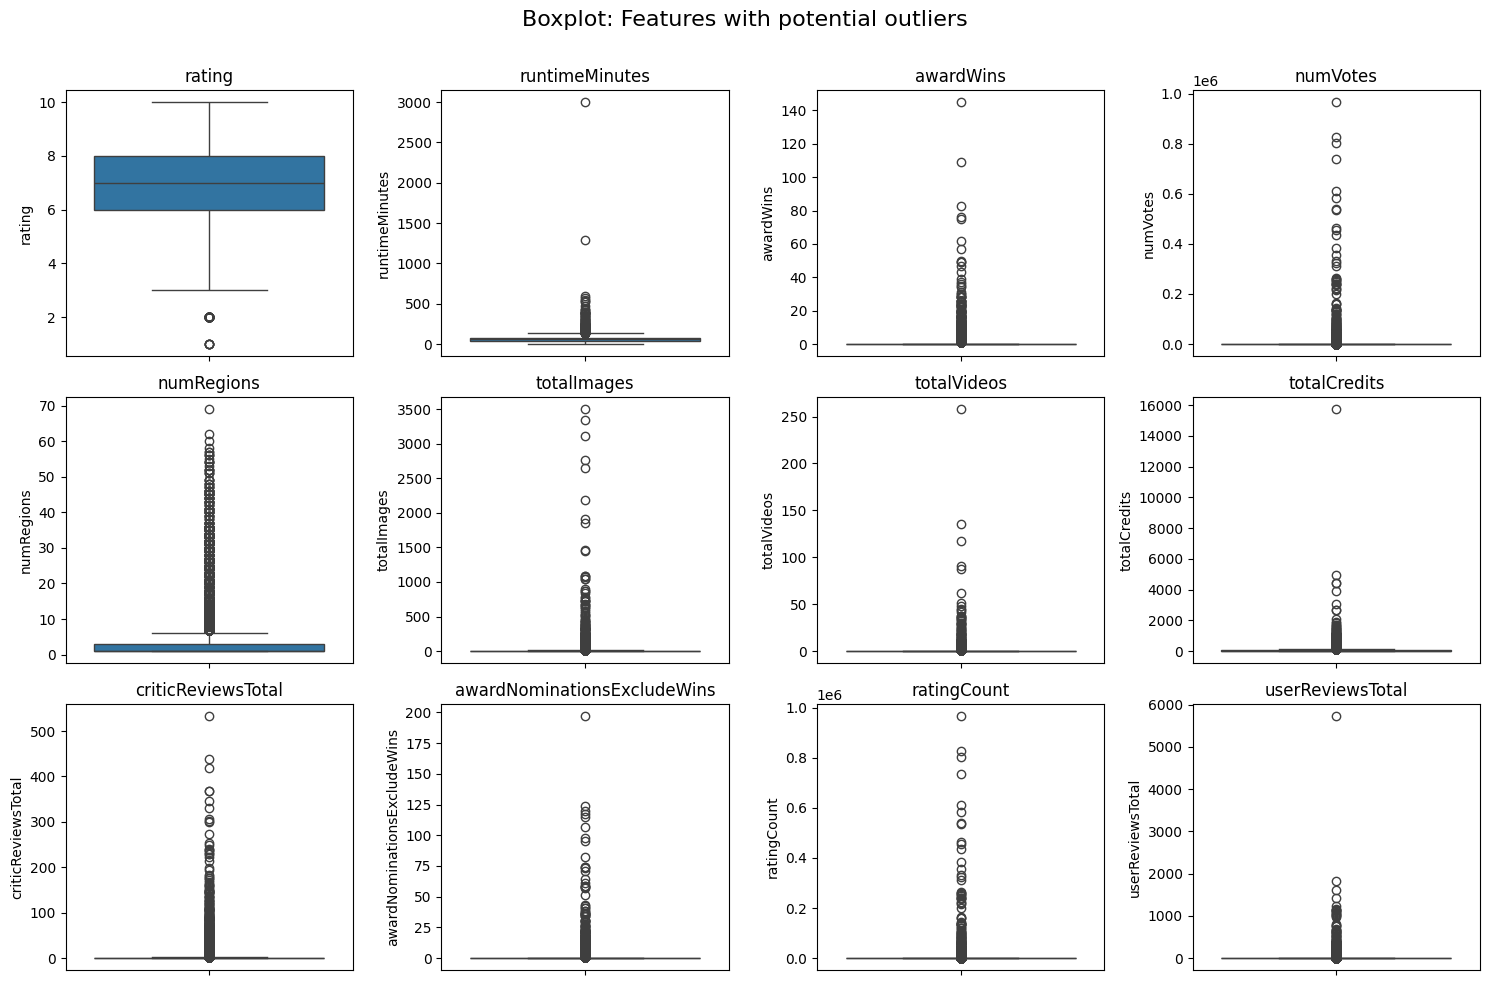

In [27]:
# Lista delle caratteristiche con outliers
features_outliers = common_outlier_columns.tolist()

# Definisci la figura con subfigure
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(15, 10))
fig.suptitle("Boxplot: Features with potential outliers", fontsize=16)

# Genera i boxplot separati per ogni caratteristica
for idx, feature in enumerate(features_outliers):
    ax = axes.flatten()[idx]  # Ottieni l'asse della sottografiche
    sns.boxplot(data=numeric_data_train[feature], ax=ax)
    ax.set_title(feature)
    ax.set_xlabel('')  # Rimuovi l'etichetta dell'asse x

# Ottimizza il layout per una disposizione più compatta
plt.tight_layout()
plt.subplots_adjust(top=0.9)

# Mostra la figura
plt.show()

In [28]:
num_rows = len(numeric_data_train)
print(f"Il dataset ha {num_rows} righe.")

Il dataset ha 16431 righe.


In [29]:
df_test_outliers = numeric_columns[common_outlier_columns]

def remove_outliers_iqr(df, threshold=1.5):
    filtered_df = df.copy()  # Copia del DataFrame originale

    for col in df.columns:
        data = df[col]
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        # Rimuovi le righe contenenti outlier
        filtered_df = filtered_df.loc[(data >= lower_bound) & (data <= upper_bound)]

    return filtered_df

def remove_outliers_std(df, threshold=2):
    filtered_df = df.copy()  # Copy of the original DataFrame

    for col in df.columns:
        data = df[col]
        mean = np.mean(data)
        std = np.std(data)

        lower_bound = mean - threshold * std
        upper_bound = mean + threshold * std

        # Remove rows containing outliers
        filtered_df = filtered_df.loc[(data >= lower_bound) & (data <= upper_bound)]

    return filtered_df

def remove_outliers_combined(df, threshold_iqr=1.5, threshold_std=2):
    filtered_df_iqr = remove_outliers_iqr(df, threshold_iqr)
    filtered_df_std = remove_outliers_std(df, threshold_std)

    # Get the intersection of indices from all methods
    common_indices = filtered_df_iqr.index.intersection(filtered_df_std.index)

    return df.loc[common_indices]


filtered_df1 = remove_outliers_iqr(df_test_outliers)
filtered_df2 = remove_outliers_std(df_test_outliers)
print(f"IQR:{filtered_df1.shape}, {(1-filtered_df1.shape[0]/numeric_data_train.shape[0])*100:.2f}% samples cut")
print(f"stDev:{filtered_df2.shape}, {(1-filtered_df2.shape[0]/numeric_data_train.shape[0])*100:.2f}% samples cut")

df_test_outliers = remove_outliers_combined(df_test_outliers)
print(f"Combined:{df_test_outliers.shape}, {(1-df_test_outliers.shape[0]/numeric_data_train.shape[0])*100:.2f}% samples cut")

IQR:(9108, 12), 44.57% samples cut
stDev:(14113, 12), 14.11% samples cut
Combined:(8528, 12), 48.10% samples cut


Given the results of the tests, it's drastic to reduce the dataset of almost the 50%. For this reason, outliers will not be removed.

Let's analyze the correlations between columns.

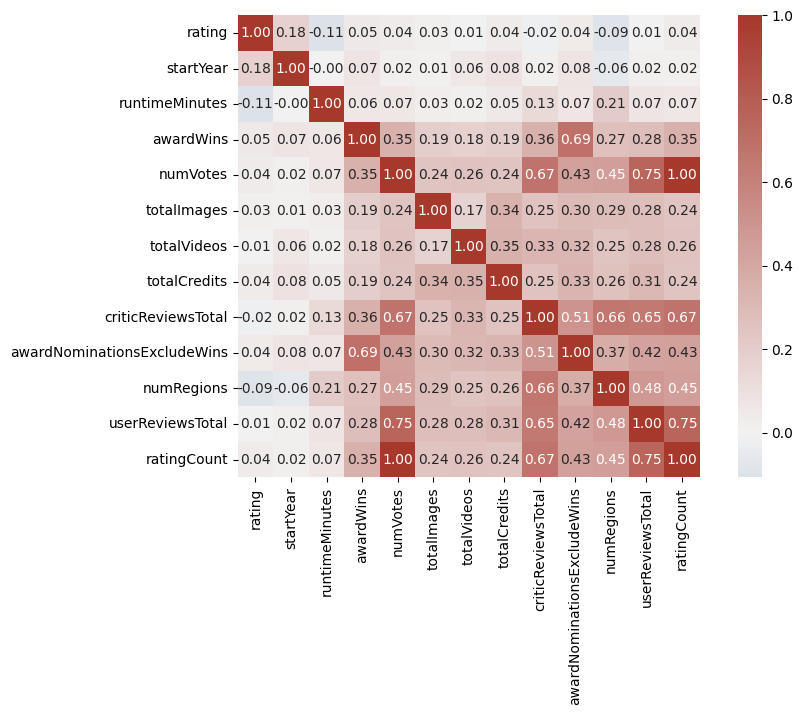

In [30]:
int_columns = data_train.select_dtypes(include='int')

corr_matrix = int_columns.corr()

plt.figure(figsize=(10,6))

# Create a custom diverging palette
cmap = sns.diverging_palette(250, 15, s=75, l=40,
                             n=9, center="light", as_cmap=True)

_ = sns.heatmap(corr_matrix, center=0, annot=True,
                fmt='.2f', square=True, cmap=cmap)


numVotes and ratingCount: Correlation of 1.00, indicating these two features are likely identical or very closely related. Therefore, ratingCount will be dropped.

In [31]:
data_train = data_train.drop(columns='ratingCount')
data_test = data_test.drop(columns='ratingCount')

# also from the numeric datasets
numeric_data_train = numeric_data_train.drop(columns='ratingCount')
numeric_data_test = numeric_data_test.drop(columns='ratingCount')

data_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16431 entries, 0 to 16430
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   originalTitle                16431 non-null  object
 1   rating                       16431 non-null  int64 
 2   startYear                    16431 non-null  int64 
 3   runtimeMinutes               16431 non-null  int64 
 4   awardWins                    16431 non-null  int64 
 5   numVotes                     16431 non-null  int64 
 6   totalImages                  16431 non-null  int64 
 7   totalVideos                  16431 non-null  int64 
 8   totalCredits                 16431 non-null  int64 
 9   criticReviewsTotal           16431 non-null  int64 
 10  titleType                    16431 non-null  object
 11  awardNominationsExcludeWins  16431 non-null  int64 
 12  canHaveEpisodes              16431 non-null  bool  
 13  isAdult                      16

In [32]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16431 entries, 0 to 16430
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   originalTitle                16431 non-null  object
 1   rating                       16431 non-null  int64 
 2   startYear                    16431 non-null  int64 
 3   runtimeMinutes               16431 non-null  int64 
 4   awardWins                    16431 non-null  int64 
 5   numVotes                     16431 non-null  int64 
 6   totalImages                  16431 non-null  int64 
 7   totalVideos                  16431 non-null  int64 
 8   totalCredits                 16431 non-null  int64 
 9   criticReviewsTotal           16431 non-null  int64 
 10  titleType                    16431 non-null  object
 11  awardNominationsExcludeWins  16431 non-null  int64 
 12  canHaveEpisodes              16431 non-null  bool  
 13  isAdult                      16

Finally, the Normalization process. Given the fact that we kept the outliers, StandardScaler (Z-Score) is the best choice.

In [33]:
# Initialize the scaler
scaler = StandardScaler()

columns_to_scale = ['rating', 'runtimeMinutes', 'awardWins', 'numVotes', 'totalImages', 'totalVideos', 
                    'totalCredits', 'criticReviewsTotal', 'awardNominationsExcludeWins', 'numRegions', 'userReviewsTotal']

scaled_train = numeric_data_train.copy()
scaled_test = numeric_data_test.copy()

# Fit the scaler on the training set and transform both train and test sets
scaled_train[columns_to_scale] = scaler.fit_transform(numeric_data_train[columns_to_scale])
scaled_test[columns_to_scale] = scaler.transform(numeric_data_test[columns_to_scale])

# Convert the scaled data back to DataFrame (optional, for readability)
scaled_train = pd.DataFrame(scaled_train, columns=numeric_data_train.columns)
scaled_test = pd.DataFrame(scaled_test, columns=numeric_data_test.columns)

# Verify standardization
print(scaled_train[columns_to_scale].mean(axis=0))  # Should be approximately 0
print(scaled_train[columns_to_scale].std(axis=0))   # Should be approximately 1

# Test set statistics (mean and std might differ but should follow the same scaling)
print(scaled_test[columns_to_scale].mean(axis=0))
print(scaled_test[columns_to_scale].std(axis=0))

rating                        -3.156815e-17
runtimeMinutes                -1.032451e-17
awardWins                      1.362187e-17
numVotes                      -8.378532e-19
totalImages                   -8.358261e-18
totalVideos                    9.135302e-18
totalCredits                   1.623003e-17
criticReviewsTotal             1.254077e-17
awardNominationsExcludeWins   -2.048686e-17
numRegions                    -1.405431e-17
userReviewsTotal               4.527110e-18
dtype: float64
rating                         1.00003
runtimeMinutes                 1.00003
awardWins                      1.00003
numVotes                       1.00003
totalImages                    1.00003
totalVideos                    1.00003
totalCredits                   1.00003
criticReviewsTotal             1.00003
awardNominationsExcludeWins    1.00003
numRegions                     1.00003
userReviewsTotal               1.00003
dtype: float64
rating                         0.000857
runtimeMinutes   

In [34]:
scaled_train[columns_to_scale].describe().T

,count,mean,std,min,25%,50%,75%,max
rating,16431.0,-3.156815e-17,1.00003,-4.438530,-0.833264,-0.112211,0.608843,2.050949
runtimeMinutes,16431.0,-1.032451e-17,1.00003,-1.384226,-0.470037,-0.035798,0.444152,67.179942
awardWins,16431.0,1.362187e-17,1.00003,-0.151301,-0.151301,-0.151301,-0.151301,52.906353
numVotes,16431.0,-8.378532e-19,1.00003,-0.073851,-0.073355,-0.072312,-0.066725,47.925127
totalImages,16431.0,-8.358261e-18,1.00003,-0.154569,-0.141101,-0.141101,-0.073763,47.036079
totalVideos,16431.0,9.135302e-18,1.00003,-0.087149,-0.087149,-0.087149,-0.087149,82.728502
totalCredits,16431.0,1.623003e-17,1.00003,-0.352515,-0.260568,-0.157127,0.021022,90.112430
criticReviewsTotal,16431.0,1.254077e-17,1.00003,-0.180750,-0.180750,-0.180750,-0.115861,34.405115
awardNominationsExcludeWins,16431.0,-2.048686e-17,1.00003,-0.141301,-0.141301,-0.141301,-0.141301,49.665900
numRegions,16431.0,-1.405431e-17,1.00003,-0.435427,-0.435427,-0.435427,-0.093809,11.179584


In [35]:
# Save the DataFrames in "clean data" folder
"""numeric_data_train.to_csv('clean data/not_scaled_train.csv', index=False)
numeric_data_test.to_csv('clean data/not_scaled_test.csv', index=False)
scaled_train.to_csv('clean data/scaled_train.csv', index=False)
scaled_test.to_csv('clean data/scaled_test.csv', index=False)"""

"numeric_data_train.to_csv('clean data/not_scaled_train.csv', index=False)\nnumeric_data_test.to_csv('clean data/not_scaled_test.csv', index=False)\nscaled_train.to_csv('clean data/scaled_train.csv', index=False)\nscaled_test.to_csv('clean data/scaled_test.csv', index=False)"